In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
df=pd.read_csv('C:\\Users\\salma\\Downloads\\data_analysis_NTI\\python\\task3\\AmesHousing.csv')

In [3]:
df.head(10)

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900
5,6,527105030,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,195500
6,7,527127150,120,RL,41.0,4920,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,213500
7,8,527145080,120,RL,43.0,5005,Pave,NaN,IR1,HLS,...,0,NaN,NaN,NaN,0,1,2010,WD,Normal,191500
8,9,527146030,120,RL,39.0,5389,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,3,2010,WD,Normal,236500
9,10,527162130,60,RL,60.0,7500,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,189000


In [136]:
# show all columns in the dataframe 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   Order            2930 non-null   int64   
 1   PID              2930 non-null   int64   
 2   MS SubClass      2930 non-null   int64   
 3   MS Zoning        2930 non-null   object  
 4   Lot Frontage     2440 non-null   float64 
 5   Lot Area         2930 non-null   int64   
 6   Street           2930 non-null   object  
 7   Alley            198 non-null    object  
 8   Lot Shape        2930 non-null   object  
 9   Land Contour     2930 non-null   object  
 10  Utilities        2930 non-null   object  
 11  Lot Config       2930 non-null   object  
 12  Land Slope       2930 non-null   object  
 13  Neighborhood     2930 non-null   object  
 14  Condition 1      2930 non-null   object  
 15  Condition 2      2930 non-null   object  
 16  Bldg Type        2930 non-null   object  


In [4]:
df.shape

(2930, 82)

In [6]:
# check for duplicates in the dataframe
df.duplicated().sum()

0

In [7]:
df.isna().sum()

Order               0
PID                 0
MS SubClass         0
MS Zoning           0
Lot Frontage      490
                 ... 
Mo Sold             0
Yr Sold             0
Sale Type           0
Sale Condition      0
SalePrice           0
Length: 82, dtype: int64

In [8]:
# check for correlation between the columns in the dataframe numeric columns
df.select_dtypes(include=['number']).corr()

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
Order,1.000000,0.173593,0.011797,-0.007034,0.031354,-0.048500,-0.011054,-0.052319,-0.075566,-0.030907,...,-0.011292,0.016355,0.027908,-0.024975,0.004307,0.052518,-0.006083,0.133365,-0.975993,-0.031408
PID,0.173593,1.000000,-0.001281,-0.096918,0.034868,-0.263147,0.104451,-0.343388,-0.157111,-0.229283,...,-0.051135,-0.071311,0.162519,-0.024894,-0.025735,-0.002845,-0.008260,-0.050455,0.009579,-0.246521
MS SubClass,0.011797,-0.001281,1.000000,-0.420135,-0.204613,0.039419,-0.067349,0.036579,0.043397,0.002730,...,-0.017310,-0.014823,-0.022866,-0.037956,-0.050614,-0.003434,-0.029254,0.000350,-0.017905,-0.085092
Lot Frontage,-0.007034,-0.096918,-0.420135,1.000000,0.491313,0.212042,-0.074448,0.121562,0.091712,0.222407,...,0.120084,0.163040,0.012758,0.028564,0.076666,0.173947,0.044476,0.011085,-0.007547,0.357318
Lot Area,0.031354,0.034868,-0.204613,0.491313,1.000000,0.097188,-0.034759,0.023258,0.021682,0.126830,...,0.157212,0.103760,0.021868,0.016243,0.055044,0.093775,0.069188,0.003859,-0.023085,0.266549
Overall Qual,-0.048500,-0.263147,0.039419,0.212042,0.097188,1.000000,-0.094812,0.597027,0.569609,0.429418,...,0.255663,0.298412,-0.140332,0.018240,0.041615,0.030399,0.005179,0.031103,-0.020719,0.799262
Overall Cond,-0.011054,0.104451,-0.067349,-0.074448,-0.034759,-0.094812,1.000000,-0.368773,0.047680,-0.135340,...,0.020344,-0.068934,0.071459,0.043852,0.044055,-0.016787,0.034056,-0.007295,0.031207,-0.101697
Year Built,-0.052319,-0.343388,0.036579,0.121562,0.023258,0.597027,-0.368773,1.000000,0.612095,0.313292,...,0.228964,0.198365,-0.374364,0.015803,-0.041436,0.002213,-0.011011,0.014577,-0.013197,0.558426
Year Remod/Add,-0.075566,-0.157111,0.043397,0.091712,0.021682,0.569609,0.047680,0.612095,1.000000,0.196928,...,0.217857,0.241748,-0.220383,0.037412,-0.046888,-0.011410,-0.003132,0.018048,0.032652,0.532974
Mas Vnr Area,-0.030907,-0.229283,0.002730,0.222407,0.126830,0.429418,-0.135340,0.313292,0.196928,1.000000,...,0.165467,0.143748,-0.110787,0.013778,0.065643,0.004617,0.044934,-0.000276,-0.017715,0.508285


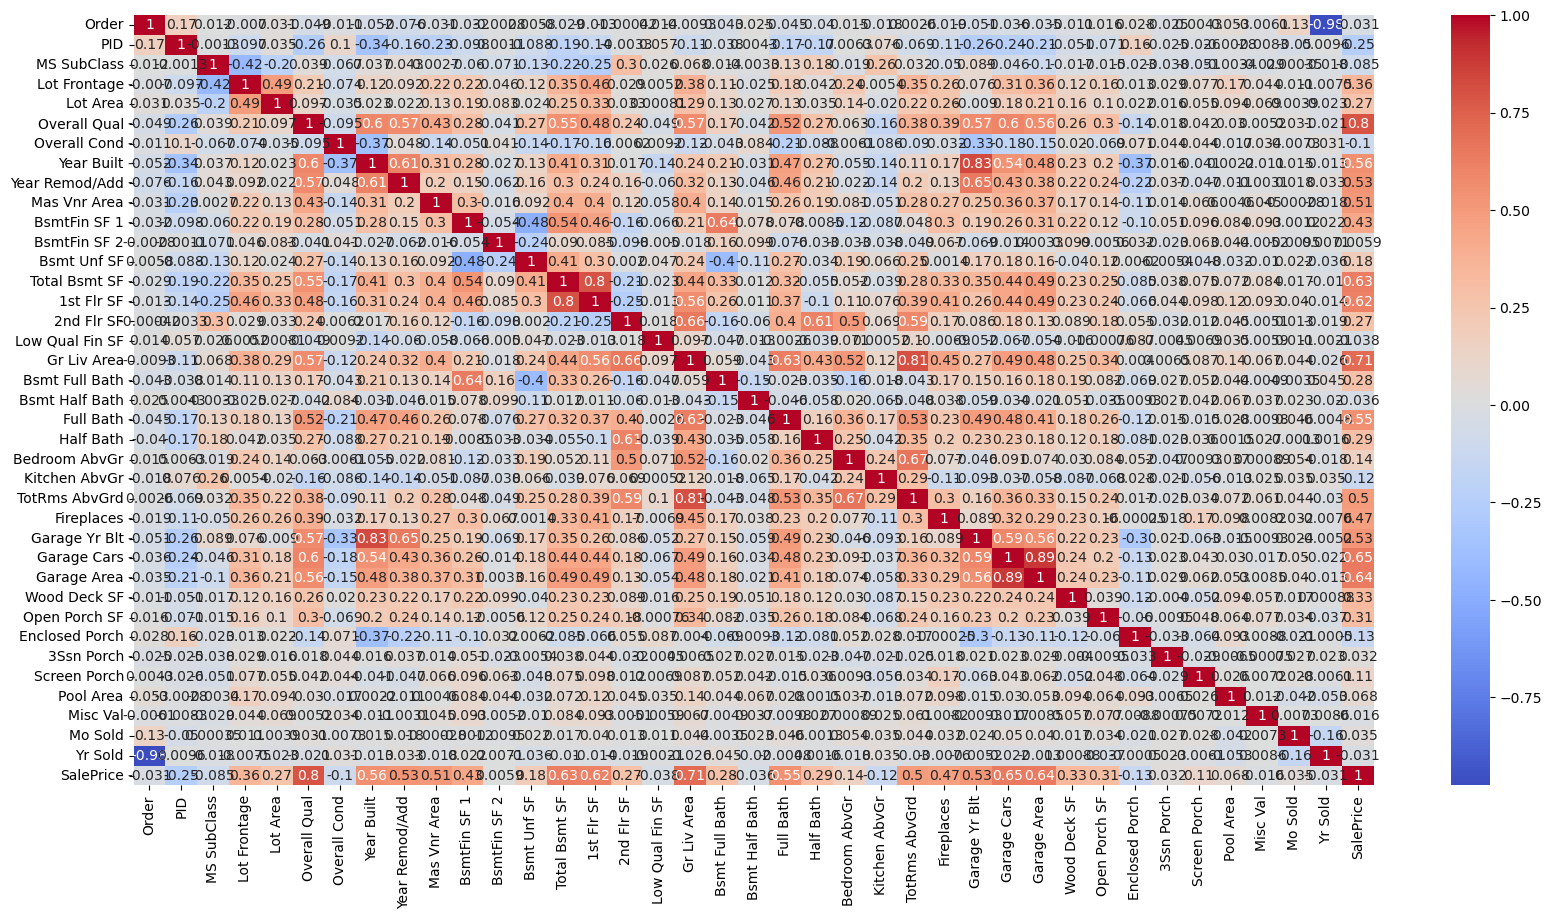

In [9]:
# heatmap to show correlation between the columns in the dataframe numeric columns
plt.figure(figsize=(20,10)) 
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True, cmap='coolwarm')
plt.show()

In [10]:
df['MS SubClass'].describe()

count    2930.000000
mean       57.387372
std        42.638025
min        20.000000
25%        20.000000
50%        50.000000
75%        70.000000
max       190.000000
Name: MS SubClass, dtype: float64

In [11]:
# use px to  create a column cart for MS SubClass
fig = px.histogram(df, x='MS SubClass')
fig.show()

In [12]:
# this a code represanting a certain type of houses
df['MS SubClass']=df['MS SubClass'].astype('category')

In [13]:
# MS Zoning column chart 
fig = px.histogram(df, x='MS Zoning')
fig.show()

In [14]:
zoning_names = {
    "A (agr)": "Agriculture",
    "C (all)": "Commercial",
    "FV": "Floating Village Residential",
    "I (all)": "Industrial",
    "RH": "Residential High Density",
    "RL": "Residential Low Density",
    "RM": "Residential Medium Density",
}

unknown = set(df["MS Zoning"].dropna().unique()) - set(zoning_names)
if unknown:
    raise ValueError(f"Unmapped MS Zoning values: {unknown}")

df["MS Zoning"] = df["MS Zoning"].map(zoning_names).astype("category")

In [15]:
# histogram to Lot Frontage 
fig=px.histogram(df,x='Lot Frontage')
fig.show()

In [16]:
missing_frontage = df["Lot Frontage"].isna()

group_medians = df.groupby(
    ["Lot Shape", "Lot Config"],
    observed=True
)["Lot Frontage"].transform("median")

df.loc[missing_frontage, "Lot Frontage"] = group_medians[missing_frontage]

print("Missing frontage remaining:", df["Lot Frontage"].isna().sum())

Missing frontage remaining: 0


In [17]:
# draw a histogram for Lot Area
fig=px.histogram(df,x='Lot Area')
fig.show()

In [18]:
alley_names = {
    "Grvl": "Gravel",
    "Pave": "Paved",
    "NA": "No alley access",
}

df["Alley"] = (
    df["Alley"]
    .fillna("NA")
    .map(alley_names)
    .astype("category")
)

df["Alley"].value_counts()

Alley
No alley access    2732
Gravel              120
Paved                78
Name: count, dtype: int64

In [19]:
df["Condition 1"] = df["Condition 1"].replace({"Norm": "Normal"})

In [20]:
df["Condition 2"] = df["Condition 2"].replace({"Norm": "Normal"})

In [22]:
# draw a bar chart for Bldg Type
fig = px.histogram(df, x='Bldg Type')
fig.show()

In [23]:
fig = px.histogram(df, x='Exterior 1st')
fig.show()

In [156]:
fig = px.histogram(df, x='Exterior 2nd')
fig.show()

In [24]:
# replace the values in the Exterior 2nd column to be more descriptive and format the values to be consistent with the Exterior 1st column
df["Exterior 2nd"] = df["Exterior 2nd"].replace({
    "Brk Cmn": "BrkComm",
    "CmentBd": "CemntBd",
    "Wd Shng": "WdShing",
})

In [25]:
df2 = pd.read_csv("AmesHousing.csv", keep_default_na=False, na_values=[""])

df["Mas Vnr Type"] = (
    df2["Mas Vnr Type"]
    .replace("None", "No veneer")
    .astype("category")
)

In [26]:
# show 2 columns Mas Vnr Type , Mas Vnr area only ,group by Mas Vnr Type = no veneer
df[df["Mas Vnr Type"] == "No veneer"][["Mas Vnr Type", "Mas Vnr Area"]]


,Mas Vnr Type,Mas Vnr Area
1,No veneer,0.0
3,No veneer,0.0
4,No veneer,0.0
6,No veneer,0.0
7,No veneer,0.0
...,...,...
2924,No veneer,0.0
2925,No veneer,0.0
2926,No veneer,0.0
2927,No veneer,0.0


In [27]:
# write a code to replace the value in the column Mas Vnr Type to NAN when mas vnr type is no veneer and mas vnr area is greater than 0
df.loc[(df["Mas Vnr Type"] == "No veneer") & (df["Mas Vnr Area"] > 0), "Mas Vnr Type"] = np.nan

In [28]:
df["Mas Vnr Type"] = df["Mas Vnr Type"].fillna("No veneer")

In [29]:
df["Mas Vnr Area"] = df["Mas Vnr Area"].fillna(0)

In [30]:
# drop the rows with the following PIDs because they have inconsistent data year built and year sold , year remod/add and year built
pids_to_drop = [
    908154195,  # Year Built 2008, but sold in 2007
    907194160,  # Year Remod/Add 2001, before Year Built 2002
]

df = df[~df["PID"].isin(pids_to_drop)].copy()

In [31]:
# histogram for Exter Condition
fig = px.histogram(df, x='Exter Cond')
fig.show()

In [32]:
# make a bar chart for foundition
fig=px.histogram(df,x='Foundation')
fig.show()

In [33]:
# NA is a non-basement house, so we will replace the NA values in the Bsmt Qual column with "No Basement" and convert the column to a categorical type
df = df.loc[df["PID"] != 903230120].copy()

df["Bsmt Qual"] = (
    df["Bsmt Qual"]
    .astype("object")
    .replace("NA", "No Basement")
    .fillna("No Basement")
    .astype("category")
)

In [34]:
# change NA to no basement for the following columns
basement_cat_cols = [
    "Bsmt Cond",
    "BsmtFin Type 1",
    "BsmtFin Type 2"
]

for col in basement_cat_cols:
    df[col] = (
        df[col]
        .astype("object")
        .fillna("No Basement")
        .astype("category")
    )

In [35]:
# fill the missing values in the Bsmt Exposure column with "No" for the following PIDs , change NA to no bassment
pids_to_fill = [528445060, 528458090, 907194130]

df.loc[df["PID"].isin(pids_to_fill), "Bsmt Exposure"] = "No"


df["Bsmt Exposure"] = (
    df["Bsmt Exposure"]
    .astype("object")
    .replace("NA", "No Basement")
    .fillna("No Basement")
    .astype("category")
)


In [36]:
# Temporarily use object dtype so category assignments work
df["BsmtFin Type 2"] = df["BsmtFin Type 2"].astype("object")

# PID 528142130: fill the missing type with mode
df.loc[df["PID"] == 528142130, "BsmtFin Type 2"] = "ALQ"

# PID 527455030: Unf means secondary finished area is zero.
# Move the 6 sq ft into unfinished area so the components still sum to the total.
pid = df["PID"] == 527455030
df.loc[pid, "BsmtFin SF 2"] = 0
df.loc[pid, "Bsmt Unf SF"] = (
    pd.to_numeric(df.loc[pid, "Total Bsmt SF"])
    - pd.to_numeric(df.loc[pid, "BsmtFin SF 1"])
)

# PID 527427230: calculate secondary area from the basement total
pid = df["PID"] == 527427230
calculated_sf2 = (
    pd.to_numeric(df.loc[pid, "Total Bsmt SF"])
    - pd.to_numeric(df.loc[pid, "BsmtFin SF 1"])
    - pd.to_numeric(df.loc[pid, "Bsmt Unf SF"])
)
df.loc[pid, "BsmtFin SF 2"] = calculated_sf2

# The calculation is 0 sq ft, so Unf matches the area
if calculated_sf2.eq(0).all():
    df.loc[pid, "BsmtFin Type 2"] = "Unf"

df["BsmtFin Type 2"] = df["BsmtFin Type 2"].astype("category")

In [37]:
df["BsmtFin Type 2"].value_counts(dropna=False)

BsmtFin Type 2
Unf            2498
Rec             106
LwQ              89
No Basement      79
BLQ              67
ALQ              54
GLQ              34
Name: count, dtype: int64

In [38]:
# check for inconsistencies between the basement finished type and area columns 
# return 0 if the basement finished type is Unf or No Basement or NA and the basement finished area 2 is not equal to 0 or
#  if the basement finished type is GLQ, ALQ, BLQ, Rec, LwQ and the basement finished area 2 is equal to 0
area2 = pd.to_numeric(df["BsmtFin SF 2"], errors="coerce")
type2 = df["BsmtFin Type 2"].astype("object")

unf_or_no_basement_with_area = type2.isin(
    ["Unf", "No Basement", "NA"]
) & area2.ne(0)

finished_type_with_zero_area = type2.isin(
    ["GLQ", "ALQ", "BLQ", "Rec", "LwQ"]
) & area2.eq(0)

df.loc[
    unf_or_no_basement_with_area | finished_type_with_zero_area,
    ["PID", "BsmtFin Type 2", "BsmtFin SF 2"]
]

,PID,BsmtFin Type 2,BsmtFin SF 2


In [39]:
electrical = (
    df["Electrical"]
    .astype("object")
    .replace(r"^\s*$", pd.NA, regex=True)
)

electrical_mode = electrical.mode().iloc[0]
df["Electrical"] = electrical.fillna(electrical_mode).astype("category")

In [40]:
# slab no basement, so we will replace the NA values in the Bsmt Full Bath column with 0 and convert the column to an integer type
df.loc[df["PID"] == 908154080, "Bsmt Full Bath"] = 0
df["Bsmt Full Bath"] = df["Bsmt Full Bath"].astype("Int64")

In [41]:
## slab no basement, so we will replace the NA values in the Bsmt Full Bath column with 0 and convert the column to an integer type
df.loc[df["PID"] == 908154080, "Bsmt Half Bath"] = 0
df["Bsmt Half Bath"] = df["Bsmt Half Bath"].astype("Int64")

In [42]:
# change 908103310, 908103320 the value of Kitchen AbvGr to 1 for the following PIDs as it have kitchen quality TA , 1 of them also have kithen counted in total rooms but not in kitchen above grade
pids = [914478020]
df.loc[df["PID"].isin(pids), "Kitchen AbvGr"] = 1

In [43]:
fireplace_qu = df["Fireplace Qu"].astype("object").replace("NA", "No Fireplace")
no_fireplace = pd.to_numeric(df["Fireplaces"], errors="coerce").eq(0)

fireplace_qu.loc[no_fireplace] = "No Fireplace"
df["Fireplace Qu"] = fireplace_qu.astype("category")

In [44]:
garage_type = df["Garage Type"].astype("object").replace("NA", "No Garage")

no_garage = (
    pd.to_numeric(df["Garage Cars"], errors="coerce").eq(0)
    & pd.to_numeric(df["Garage Area"], errors="coerce").eq(0)
)

garage_type.loc[no_garage] = "No Garage"
df["Garage Type"] = garage_type.astype("category")

In [45]:
# fill the missing values in the Garage Yr Blt column with the values in the Year Built column for the following PID 903426160 and change the value of Garage Finish to Fin
# drop row with blank garage data for PID 910201180
mask = df["PID"] == 903426160

df.loc[mask, "Garage Yr Blt"] = df.loc[mask, "Year Built"]
df.loc[mask, "Garage Finish"] = "Fin"

df = df.loc[df["PID"] != 910201180].copy()

In [46]:
# Correct the impossible garage year
garage_year = pd.to_numeric(df["Garage Yr Blt"], errors="coerce")
df.loc[garage_year.eq(2207), "Garage Yr Blt"] = 2007

# Identify homes with no garage
no_garage = (
    pd.to_numeric(df["Garage Cars"], errors="coerce").eq(0)
    & pd.to_numeric(df["Garage Area"], errors="coerce").eq(0)
)

# Replace the no-garage code, including values pandas parsed as missing
garage_category_cols = [
    "Garage Type",
    "Garage Finish",
    "Garage Qual",
    "Garage Cond",
]

for col in garage_category_cols:
    values = df[col].astype("object").replace("NA", "No Garage")
    values.loc[no_garage] = "No Garage"
    df[col] = values.astype("category")

In [47]:
df.loc[df["PID"] == 903426160, "Garage Qual"] = "TA"

In [48]:
df.loc[df["PID"] == 903426160, "Garage Cond"] = "TA"

In [49]:
# Convert to object first so this also works if Pool QC is categorical?????????????????????4 rows 
df["Pool QC"] = df["Pool QC"].astype("object")

no_pool = pd.to_numeric(df["Pool Area"], errors="coerce").eq(0)
df.loc[no_pool, "Pool QC"] = "No Pool"

df["Pool QC"] = df["Pool QC"].astype("category")

# Check the result
print(df.loc[no_pool, "Pool QC"].value_counts(dropna=False))
print("Remaining missing values:", df["Pool QC"].isna().sum())

Pool QC
No Pool    2913
Ex            0
Fa            0
Gd            0
TA            0
Name: count, dtype: int64
Remaining missing values: 0


In [50]:
df["Fence"] = df["Fence"].astype("object")

no_fence = (
    df["Fence"].isna()
    | df["Fence"].astype("string").str.strip().str.upper().eq("NA")
)

df.loc[no_fence, "Fence"] = "No Fence"
df["Fence"] = df["Fence"].astype("category")

print(df["Fence"].value_counts(dropna=False))

Fence
No Fence    2356
MnPrv        328
GdPrv        118
GdWo         112
MnWw          12
Name: count, dtype: int64


In [51]:
df["Misc Feature"] = df["Misc Feature"].astype("object")

no_feature = (
    df["Misc Feature"].isna()
    | df["Misc Feature"].astype("string").str.strip().str.upper().eq("NA")
)
df.loc[no_feature, "Misc Feature"] = "No Miscellaneous Feature"
df["Misc Feature"] = df["Misc Feature"].astype("category")



In [52]:
df["Sale Type"] = df["Sale Type"].astype("string").str.strip().astype("category")

In [53]:
df.isna().sum()

Order             0
PID               0
MS SubClass       0
MS Zoning         0
Lot Frontage      0
                 ..
Mo Sold           0
Yr Sold           0
Sale Type         0
Sale Condition    0
SalePrice         0
Length: 82, dtype: int64

In [ ]:
# unclean dataframe shape was (2930, 82)
df.shape

(2926, 82)

In [54]:
df.head(10)


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,Residential Low Density,141.0,31770,Pave,No alley access,IR1,Lvl,...,0,No Pool,No Fence,No Miscellaneous Feature,0,5,2010,WD,Normal,215000
1,2,526350040,20,Residential High Density,80.0,11622,Pave,No alley access,Reg,Lvl,...,0,No Pool,MnPrv,No Miscellaneous Feature,0,6,2010,WD,Normal,105000
2,3,526351010,20,Residential Low Density,81.0,14267,Pave,No alley access,IR1,Lvl,...,0,No Pool,No Fence,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,Residential Low Density,93.0,11160,Pave,No alley access,Reg,Lvl,...,0,No Pool,No Fence,No Miscellaneous Feature,0,4,2010,WD,Normal,244000
4,5,527105010,60,Residential Low Density,74.0,13830,Pave,No alley access,IR1,Lvl,...,0,No Pool,MnPrv,No Miscellaneous Feature,0,3,2010,WD,Normal,189900
5,6,527105030,60,Residential Low Density,78.0,9978,Pave,No alley access,IR1,Lvl,...,0,No Pool,No Fence,No Miscellaneous Feature,0,6,2010,WD,Normal,195500
6,7,527127150,120,Residential Low Density,41.0,4920,Pave,No alley access,Reg,Lvl,...,0,No Pool,No Fence,No Miscellaneous Feature,0,4,2010,WD,Normal,213500
7,8,527145080,120,Residential Low Density,43.0,5005,Pave,No alley access,IR1,HLS,...,0,No Pool,No Fence,No Miscellaneous Feature,0,1,2010,WD,Normal,191500
8,9,527146030,120,Residential Low Density,39.0,5389,Pave,No alley access,IR1,Lvl,...,0,No Pool,No Fence,No Miscellaneous Feature,0,3,2010,WD,Normal,236500
9,10,527162130,60,Residential Low Density,60.0,7500,Pave,No alley access,Reg,Lvl,...,0,No Pool,No Fence,No Miscellaneous Feature,0,6,2010,WD,Normal,189000
